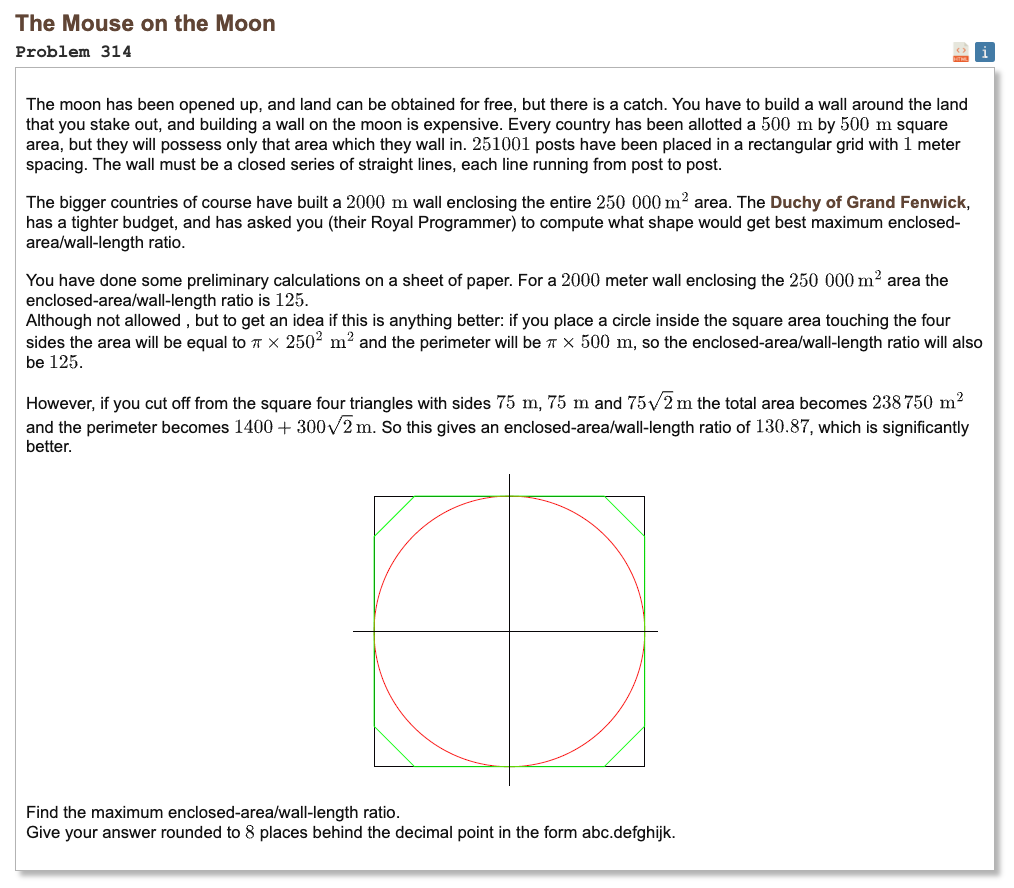

## Initial approach

* think of the final shape as a square with four identical rounded corner cuts
* each corner cut is a path between lattice posts
* for any candidate path, compute the area removed and the wall length added
* compare shapes by their enclosed area divided by wall length
* the best path is very close to a circular arc, but must use grid posts
* search around that arc and keep improving the best valid polygon
* round the final maximum ratio to eight decimal places

In [1]:
import math

def corner_path(radius):
    points = []

    for x in range(radius + 1):
        y = round(math.sqrt(radius * radius - x * x))
        if 0 <= y <= radius:
            points.append((x, y))

    cleaned = []
    last_y = None

    for x, y in points:
        if y != last_y:
            cleaned.append((x, y))
            last_y = y

    if cleaned[0] != (0, radius):
        cleaned.insert(0, (0, radius))

    if cleaned[-1] != (radius, 0):
        cleaned.append((radius, 0))

    return cleaned

def path_area_and_length(path):
    area = 0
    length = 0

    for i in range(len(path) - 1):
        x1, y1 = path[i]
        x2, y2 = path[i + 1]

        area += (x2 - x1) * (y1 + y2) / 2
        length += math.hypot(x2 - x1, y2 - y1)

    return area, length

def ratio_from_path(path, side):
    cut_distance = path[-1][0]
    cut_area, cut_length = path_area_and_length(path)

    total_area = side * side - 4 * cut_area
    total_length = 4 * side - 8 * cut_distance + 4 * cut_length

    return total_area / total_length

def solve():
    side = 500
    best = 0

    for radius in range(1, side + 1):
        path = corner_path(radius)
        value = ratio_from_path(path, side)

        if value > best:
            best = value

    return best

In [2]:
%%time
result = solve()
print("Result:", f"{result:.8f}")

Result: 126.92772416
CPU times: user 42.9 ms, sys: 898 μs, total: 43.8 ms
Wall time: 43.2 ms
